# 02 — Clustering and Cell-Type Annotation

Loads the cleaned checkpoint, normalises and reduces dimensionality, clusters
cells with the Leiden algorithm, annotates clusters by marker-gene expression,
removes low-quality clusters, and saves an annotated checkpoint
(`msc_annotated.h5ad`).

In [ ]:
import sys
!{sys.executable} -m pip install --force-reinstall "numpy==1.26.4" --quiet
!{sys.executable} -m pip install scanpy anndata scikit-image python-igraph leidenalg --quiet

from google.colab import drive
drive.mount('/content/drive')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 55.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scanpy 1.12.4 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
anndata 0.13.3.post0 requires numpy>=2.1, but you have numpy 1.26.4 which is incompatible.
fast-array-utils 1.5 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
zarr 3.3.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.5 which is incompatible.
jax 0.11.1 requires numpy>=2.1, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.11.0 requires numpy>=2.0, but you 

In [ ]:
import scanpy as sc
import anndata as ad

adata = ad.read_h5ad("/content/drive/MyDrive/roux_project/msc_clean_raw.h5ad")
print(adata.shape)
print("raw_count layer present:", 'raw_count' in adata.layers)

# normalise, log, select HVG, scale, and run PCA
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata.raw = adata
adata = adata[:, adata.var['highly_variable']].copy()
sc.pp.scale(adata, max_value=10)
sc.pp.pca(adata, svd_solver='arpack')
print(adata)

(10018, 19321)
raw_count layer present: True


/usr/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


AnnData object with n_obs × n_vars = 10018 × 2000
    obs: 'batch', 'n_genes', 'perc_mito', 'age', 'log10_n_counts', 'combination_short', 'age_combination_short', '_scvi_batch', '_scvi_labels', '_scvi_local_l_mean', '_scvi_local_l_var', 'predicted_doublet', 'doublet_score'
    var: 'gene_id_orig-0', 'gene_id-0', 'gene_name-0', 'contig-0', 'gene_biotype-0', 'n_splice_sites-0', 'length-0', 'pseudogene_status-0', 'transcript_support_level-0', 'mitochondrial-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells-0', 'gene_id_orig-1', 'gene_id-1', 'gene_name-1', 'contig-1', 'gene_biotype-1', 'n_splice_sites-1', 'length-1', 'pseudogene_status-1', 'transcript_support_level-1', 'mitochondrial-1', 'highly_variable-1', 'means-1', 'dispersions-1', 'dispersions_norm-1', 'n_cells-1', 'transgene-1', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: '_scvi', 'age_colors', 'batch_colors', 'combination_short_colors', 'hvg', 'leiden_colors

In [ ]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.leiden(adata, resolution=1.0, key_added='my_leiden')
print(adata.obs['my_leiden'].value_counts())

/tmp/ipykernel_7132/942818922.py:2: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=1.0, key_added='my_leiden')


my_leiden
0     1425
1     1284
2     1180
3      794
4      754
5      685
6      634
7      609
8      523
9      511
10     443
11     419
12     305
13     162
14     134
15      67
16      48
17      35
18       6
Name: count, dtype: int64


In [ ]:
sc.tl.rank_genes_groups(adata, groupby='my_leiden', method='wilcoxon')

import pandas as pd
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
top = pd.DataFrame({group: result['names'][group][:10] for group in groups})
print(top)

          0         1           2         3          4         5       6  \
0  Serpinf1     Aebp1         Fos      Ldha    Serinc1       Mgp    Ftl1   
1       Bgn      Ebf1        Egr1  Eif4ebp1    Prkar1a     Ltbp1  S100a6   
2    Efemp2     Sned1        Junb  Serpinh1      Ccng1     Dusp1  Cox6a1   
3    Pcolce     Il1r1          F3      Tpi1   Atp6v1b2       Pam   Cox7b   
4  Lgals3bp     Bicc1  Mir124-2hg     Eif5a       Ass1      Prg4    Ppia   
5   Gm10076    Mycbp2      Npffr1     Acta2      Gpnmb    S100a1   Calm3   
6     Mfap2    Malat1       Hif1a   Prelid1       Ftl1  EU599041   Rplp1   
7    Olfml3   Col14a1       Srsf5      Rpsa    Atp6v1a       Scx  Myl12a   
8     Rpl36      Gas6       Cyr61     Rpl14  Hist1h2bc      Il33  Myeov2   
9     Tmed3  Serping1     B4galt1      Rpl8      Mob1b     Prrx2   Tceb2   

        7          8      9      10      11             12      13      14  \
0    Eprs       Mpp1  Thbs4   Cenpa   Anxa3  2810417H13Rik   Ifit3    Gclm   
1    Rp

/tmp/ipykernel_7132/3543167165.py:10: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.dotplot(adata, marker_genes, groupby='my_leiden', save='_validate.png')


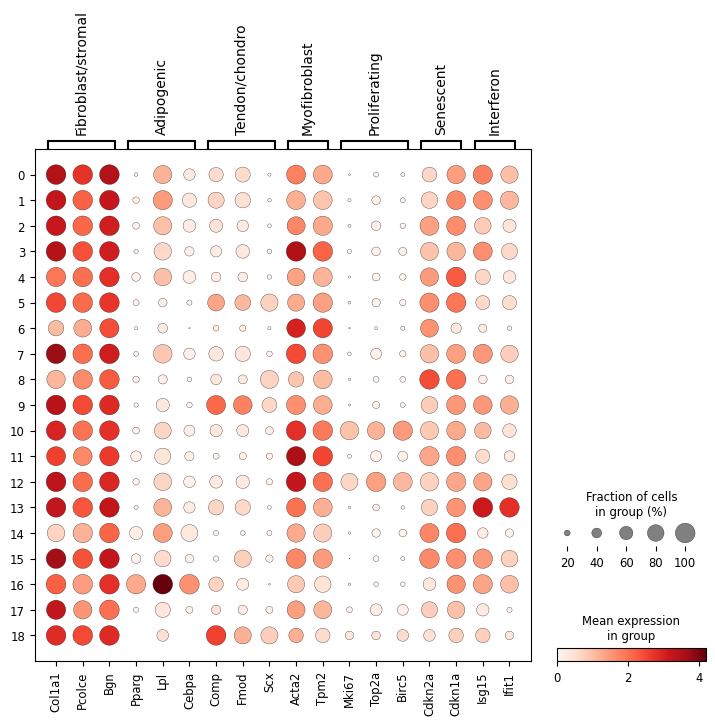

In [ ]:
marker_genes = {
    'Fibroblast/stromal': ['Col1a1', 'Pcolce', 'Bgn'],
    'Adipogenic': ['Pparg', 'Lpl', 'Cebpa'],
    'Tendon/chondro': ['Comp', 'Fmod', 'Scx'],
    'Myofibroblast': ['Acta2', 'Tpm2'],
    'Proliferating': ['Mki67', 'Top2a', 'Birc5'],
    'Senescent': ['Cdkn2a', 'Cdkn1a'],
    'Interferon': ['Isg15', 'Ifit1'],
}
sc.pl.dotplot(adata, marker_genes, groupby='my_leiden', save='_validate.png')

In [ ]:
probe_genes = {
    'Endothelial': ['Pecam1', 'Cdh5', 'Kdr'],
    'Immune/macrophage': ['Ptprc', 'Cd68', 'Lyz2'],
    'Pericyte/mural': ['Rgs5', 'Pdgfrb', 'Notch3'],
    'Osteogenic': ['Runx2', 'Sp7', 'Bglap'],
    'Chondrogenic': ['Sox9', 'Acan', 'Col2a1'],
    'Senescence(broad)': ['Cdkn2a', 'Cdkn1a', 'Glb1', 'Serpine1'],
}
present = {k: [g for g in v if g in adata.var_names] for k, v in probe_genes.items()}
print(present)

{'Endothelial': [], 'Immune/macrophage': ['Cd68', 'Lyz2'], 'Pericyte/mural': ['Rgs5'], 'Osteogenic': ['Bglap'], 'Chondrogenic': ['Sox9', 'Col2a1'], 'Senescence(broad)': ['Cdkn2a', 'Cdkn1a', 'Serpine1']}


/tmp/ipykernel_7132/961895862.py:8: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.dotplot(adata, probe_present, groupby='my_leiden', save='_probe.png')


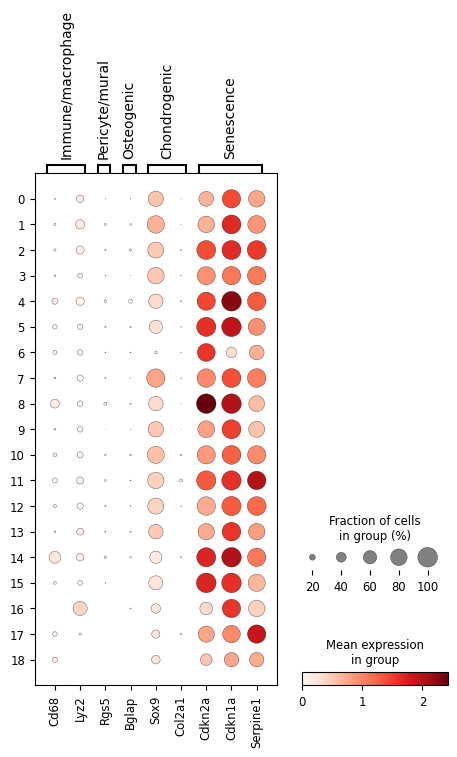

In [ ]:
probe_present = {
    'Immune/macrophage': ['Cd68', 'Lyz2'],
    'Pericyte/mural': ['Rgs5'],
    'Osteogenic': ['Bglap'],
    'Chondrogenic': ['Sox9', 'Col2a1'],
    'Senescence': ['Cdkn2a', 'Cdkn1a', 'Serpine1'],
}
sc.pl.dotplot(adata, probe_present, groupby='my_leiden', save='_probe.png')

In [ ]:
for cl in ['4', '8', '6', '14', '15']:
    genes = adata.uns['rank_genes_groups']['names'][cl][:20]
    print(f"\nCluster {cl} top 20:")
    print(list(genes))


Cluster 4 top 20:
['Serinc1', 'Prkar1a', 'Ccng1', 'Atp6v1b2', 'Ass1', 'Gpnmb', 'Ftl1', 'Atp6v1a', 'Hist1h2bc', 'Mob1b', 'Hist1h4i', 'Cdkn1a', 'Gla', 'Tpp1', 'Tmed7', 'Psap', 'Hist1h4h', 'Ctsb', 'Trp53inp1', 'Nudt4']

Cluster 8 top 20:
['Mpp1', 'Tle1', 'Cdkn2a', 'Rnf11', 'Spp1', 'Perp', 'Gabarapl2', 'Gja1', 'Lgals3', 'Aqp5', 'Hbegf', 'Scx', 'Itgbl1', 'Mapk13', 'Atp6v0e', 'Atp6v1g1', 'Hoxd10', 'Sema3a', 'Mkx', 'Cpe']

Cluster 6 top 20:
['Ftl1', 'S100a6', 'Cox6a1', 'Cox7b', 'Ppia', 'Calm3', 'Rplp1', 'Myl12a', 'Myeov2', 'Tceb2', 'Cox6b1', 'Lgals1', 'Nap1l1', 'Fkbp1a', 'Dap', 'Rps26', 'S100a4', 'Cox8a', 'Bag1', 'Cox6c']

Cluster 14 top 20:
['Gclm', 'Esd', 'Prdx1', 'Cyb5a', 'Srxn1', 'Blvrb', 'Gstm1', 'Taldo1', 'Sqstm1', 'Txnrd1', 'Nqo1', 'Maoa', 'Gbe1', 'Prdx6', 'Rtn4', 'Gpr137b', 'Pgd', 'Gclc', 'Ftl1', 'Slc7a11']

Cluster 15 top 20:
['Syt13', 'Arhgdib', 'Crabp1', 'Irx1', 'Tgfbi', 'Gm26809', 'Casp1', 'Ctsk', 'Lgals3', 'Bcl11b', 'Rps2', 'Ccl7', 'Rps23', 'Rpl7a', 'Kitl', 'Ly6c1', 'Rplp0', 'As

## Cluster annotation

Cluster identities were assigned from the marker-gene rankings above. Clusters 17
and 18 lacked coherent identity markers (dominated by nuclear/housekeeping
transcripts) and were designated low-quality and removed. No endothelial,
immune, or pericyte populations were detected, confirming a pure mesenchymal
dataset.

In [ ]:
cluster_to_celltype = {
    '0': 'Fibroblast/stromal',
    '1': 'Fibroblast/stromal',
    '2': 'Fibroblast/stromal',
    '3': 'Myofibroblast',
    '4': 'Senescent/stressed',
    '5': 'Tendon',
    '6': 'Fibroblast/stromal',
    '7': 'Fibroblast/stromal',
    '8': 'Tendon',
    '9': 'Tendon',
    '10': 'Proliferating',
    '11': 'Myofibroblast',
    '12': 'Proliferating',
    '13': 'Interferon',
    '14': 'Oxidative-stress',
    '15': 'Inflammatory/secretory',
    '16': 'Adipogenic',
    '17': 'Low-quality',
    '18': 'Low-quality',
}
adata.obs['cell_type'] = adata.obs['my_leiden'].map(cluster_to_celltype).astype('category')
print(adata.obs['cell_type'].value_counts())

cell_type
Fibroblast/stromal        5132
Tendon                    1719
Myofibroblast             1213
Senescent/stressed         754
Proliferating              748
Interferon                 162
Oxidative-stress           134
Inflammatory/secretory      67
Adipogenic                  48
Low-quality                 41
Name: count, dtype: int64


In [ ]:
adata = adata[adata.obs['cell_type'] != 'Low-quality'].copy()
print(adata.shape)

adata.write_h5ad("/content/drive/MyDrive/roux_project/msc_annotated.h5ad")
print("saved")

(9977, 2000)
saved


/tmp/ipykernel_7132/3916370298.py:2: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


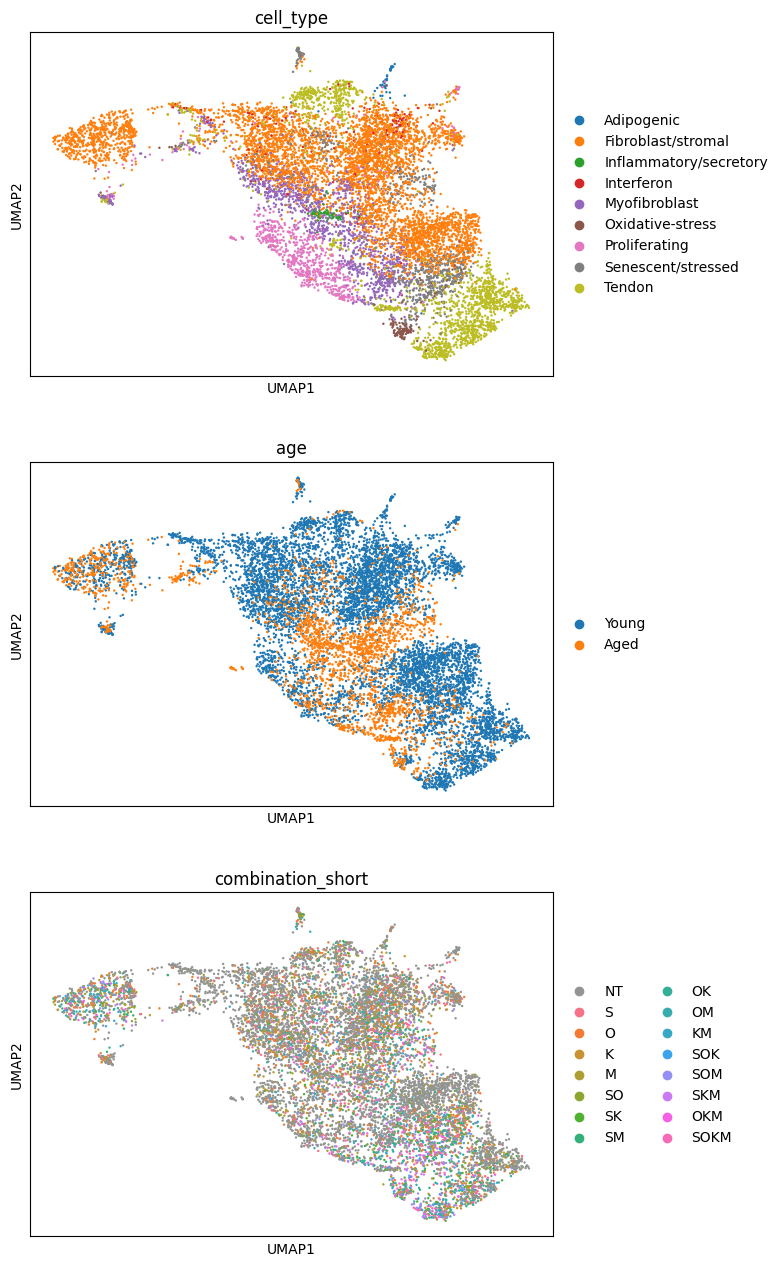

In [ ]:
import matplotlib.pyplot as plt
sc.pl.umap(
    adata,
    color=['cell_type', 'age', 'combination_short'],
    ncols=1,
    save='_overview.png'
)